# Constructing the Tissue State Axis feature ontology

Below is the pipeline used to generate hierarchical meta-MOFA models at the biopsy-level, which define tissue state axes integrated between cell-type-resolved expression and cell type composition. This notebook shows the feature-level ontology construction for tissue state axes; see Tutorial 9 for the biopsy-level model.

# Import packages

In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import muon as mu
import re
import gseapy as gp
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import scfo
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

In [2]:
def quadrant_plot(x_mean, y_mean, min_metric = 0, figsize = (14, 14), 
                  x_label = "Out of infusion zone vs Implant", y_label = "Within infusion zone vs Implant",
                  n_genes = 30, text_spacing = 0.019, fontsize = 14, dotsize = 25, xlim_pad = 1.1, ylim_pad = 1.1,
                 save_svg = False, save_path = 'Manuscript/Figures/TPT_svg/', file_name = 'default.svg', 
                  text_color = 'black', dot_color = None, dot_cmap = 'bwr', fontstyle = 'normal'
                 ):

    # common_genes = list(set(x_mean.index) & set(y_mean.index))
    # x_mean = x_mean.loc[common_genes]
    # y_mean = y_mean.loc[common_genes]  
    
    # gene_universe = list(set(x_mean[x_mean.abs() > min_metric].index) & set(y_mean[y_mean.abs() > min_metric].index))
    # x_mean = x_mean.loc[gene_universe]
    # y_mean = y_mean.loc[gene_universe]
      
    
    plt.rcParams['svg.fonttype'] = 'none'
    fig, ax = plt.subplots(figsize=figsize)

    ax.axhline(0, c='grey', lw=1.5, zorder=0)
    ax.axvline(0, c='grey', lw=1.5, zorder=0)
    if dot_color is not None:
        ax.scatter(x_mean, y_mean, c=dot_color, cmap = dot_cmap, edgecolor='black', s = dotsize)
    else:
        ax.scatter(x_mean, y_mean, c='grey', edgecolor='black', s = dotsize)
    
    # Get plot limits
    xlim = (-xlim_pad*x_mean.abs().max(), xlim_pad*x_mean.abs().max())
    ylim = (-ylim_pad*y_mean.abs().max(), ylim_pad*y_mean.abs().max())

    x_mean = pd.to_numeric(pd.Series(x_mean), errors='coerce')
    y_mean = pd.to_numeric(pd.Series(y_mean), errors='coerce')
    distance = np.sqrt(x_mean**2 + y_mean**2)
    
    # Assign quadrant
    quadrants = pd.Series(index=x_mean.index, dtype='object')
    quadrants[(x_mean > 0) & (y_mean > 0)] = 'Q1'
    quadrants[(x_mean < 0) & (y_mean > 0)] = 'Q2'
    quadrants[(x_mean < 0) & (y_mean < 0)] = 'Q3'
    quadrants[(x_mean > 0) & (y_mean < 0)] = 'Q4'
    
    # Define quadrant label layout
    corner_labels = {
        'Q1': {'x': xlim[1] - 0.01 * (xlim[1] - xlim[0]), 'y_start': ylim[1] - 0.01 * (ylim[1] - ylim[0]), 'ha': 'right', 'va': 'top'},
        'Q2': {'x': xlim[0] + 0.01 * (xlim[1] - xlim[0]), 'y_start': ylim[1] - 0.01 * (ylim[1] - ylim[0]), 'ha': 'left',  'va': 'top'},
        'Q3': {'x': xlim[0] + 0.01 * (xlim[1] - xlim[0]), 'y_start': ylim[0] + 0.01 * (ylim[1] - ylim[0]), 'ha': 'left',  'va': 'bottom'},
        'Q4': {'x': xlim[1] - 0.01 * (xlim[1] - xlim[0]), 'y_start': ylim[0] + 0.01 * (ylim[1] - ylim[0]), 'ha': 'right', 'va': 'bottom'},
    }
    
    top_n = n_genes
    for q, info in corner_labels.items():
        genes_in_q = quadrants[quadrants == q].index
        top_genes_in_q = distance.loc[genes_in_q].sort_values(ascending=False).head(top_n).index.tolist()
    
        if y_mean.loc[top_genes_in_q].mean() > 0:
            top_genes_in_q = y_mean.loc[top_genes_in_q].sort_values(ascending = False).index
        else:
            top_genes_in_q = y_mean.loc[top_genes_in_q].sort_values(ascending = True).index
        
        x_anchor = info['x']
        y_anchor = info['y_start']
        ha = info['ha']
        va = info['va']
        spacing = (ylim[1] - ylim[0]) * text_spacing
    
        for i, gene in enumerate(top_genes_in_q):
            y_text = y_anchor - i * spacing if 'top' in va else y_anchor + i * spacing
    
            # Annotate with arrow connecting to box edge
            arrow = ax.annotate(
                gene,
                xy=(x_mean[gene], y_mean[gene]),
                xytext=(x_anchor, y_text),
                ha=ha, va=va,
                fontsize=fontsize, color=text_color, fontstyle = fontstyle,
                bbox=dict(boxstyle='round,pad=0.01', fc='none', ec='none'),
                arrowprops=dict(arrowstyle='-', linestyle=  'dashed', color='gray', lw=0.25, shrinkA=0, shrinkB=5)
            )
            arrow.arrow_patch.set_linestyle((0, (25, 10))) 
    # Final settings
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    #plt.tight_layout()
    plt.xlim(xlim)
    plt.ylim(ylim)
    
    
    if save_svg:

        fig = plt.gcf()
        ax = plt.gca()
        for coll in ax.collections:
            coll.set_rasterized(True)

        plt.savefig(
            save_path + file_name,
            format="svg",
            bbox_inches="tight",
            pad_inches=0.25,
            transparent=False,  # avoid transparency so Illustrator doesn't rasterize
        )
    
    
    plt.show()

In [3]:
def clr_transform(df, pseudocount=1e-6):
    """
    Perform centered log-ratio (CLR) transformation on a dataframe of proportions.

    Parameters
    ----------
    df : pandas.DataFrame
        Rows = biopsies (samples), columns = compositional features (cell types).
        Each row should sum to ~1.
    pseudocount : float
        Small value added to avoid log(0).

    Returns
    -------
    pandas.DataFrame
        CLR-transformed dataframe with same shape and labels.
    """
    # Add small pseudocount to avoid log(0)
    X = df + pseudocount

    # Compute geometric mean for each row
    gm = np.exp(np.log(X).mean(axis=1))

    # Compute CLR: log-ratio to geometric mean
    clr = np.log(X.div(gm, axis=0))

    return clr

def plot_pca_loadings(
    adata,
    loadings_key = 'PCs',
    n_components=5,
    top_features=None,
    figsize=(10, 4),
    sort_by_abs=True,
    palette="vlag",
    save=None
):
    """
    Plot PCA loadings for each PC in separate subplots.
    
    Parameters
    ----------
    adata : AnnData
        Must contain adata.varm["PCs"] (from sc.tl.pca).
    n_components : int
        Number of PCs to show.
    top_features : int or None
        Show top N features by absolute loading per PC (default: all).
    figsize : tuple
        (width, height) of the entire figure.
    sort_by_abs : bool
        Sort by absolute loading magnitude.
    palette : str
        Seaborn palette or colormap for bars.
    save : str or None
        Path to save figure (e.g., "pca_loadings_by_pc.svg").
    """

    # Extract loadings
    loadings = pd.DataFrame(
        adata.varm[loadings_key][:, :n_components],
        index=adata.var_names,
        columns=[f"PC{i+1}" for i in range(n_components)]
    )

    # Get variance explained if available
    var_exp = adata.uns.get("pca", {}).get("variance_ratio", None)
    if var_exp is not None:
        var_exp = np.round(100 * var_exp[:n_components], 1)
    else:
        var_exp = [None] * n_components

    # Create figure
    fig, axes = plt.subplots(
        1, n_components, figsize=(figsize[0] * n_components, figsize[1]),
        sharey=True
    )

    if n_components == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        pc = f"PC{i+1}"
        series = loadings[pc]

        # Select top features if requested
        if top_features is not None:
            if sort_by_abs:
                series = series.reindex(series.abs().sort_values(ascending=False).index)
            series = series.head(top_features)
        else:
            if sort_by_abs:
                series = series.reindex(series.abs().sort_values(ascending=False).index)

        # Plot horizontal bars
        sns.barplot(
            y=series.index,
            x=series.values,
            palette=palette,
            ax=ax
        )
        ax.axvline(0, color="black", lw=0.8)
        ax.set_title(
            f"{pc}" + (f"\n({var_exp[i]}% var)" if var_exp[i] is not None else "")
        )
        ax.set_xlabel("Loading weight")
        if i > 0:
            ax.set_ylabel("")

    plt.tight_layout()

    if save:
        plt.savefig(save, bbox_inches="tight", dpi=300)
    plt.show()


# Load Data

In [4]:
disease = 'gbm'

In [5]:
ontology = mu.read_h5mu('scFO_Models/scfo_mofa_'+disease+'.h5mu')

In [6]:
mean_scores_all = pd.read_csv('Data/Single_Cell_Biopsies/biopsy_factor_scores_mean_'+disease+'.csv', index_col = 0)
mean_scores_all.columns = mean_scores_all.columns.astype(str) + '::mean'
std_scores_all = pd.read_csv('Data/Single_Cell_Biopsies/biopsy_factor_scores_std_'+disease+'.csv', index_col = 0)
std_scores_all.columns = std_scores_all.columns.astype(str) + '::std'

In [7]:
metadata_all = pd.read_csv('Data/Single_Cell_Biopsies/biopsy_metadata_'+disease+'.csv', index_col = 0)
metadata = metadata_all[
    (metadata_all['Lineage enrichment'] == 'no')
    & (metadata_all['cell_used_in_disc'] == 'Yes')
].copy()
metadata_cells = metadata[metadata['Cells vs Nuclei'] == 'cell'].copy()
metadata_nuclei = metadata[metadata['Cells vs Nuclei'] == 'nucleus'].copy()

In [8]:
mean_scores_cells = mean_scores_all.loc[metadata_cells.index].copy()
std_scores_cells = std_scores_all.loc[metadata_cells.index].copy()

mean_scores_nuclei = mean_scores_all.loc[metadata_nuclei.index].copy()
std_scores_nuclei = std_scores_all.loc[metadata_nuclei.index].copy()

In [9]:
single_cell_fractions = pd.read_csv('Data/Single_Cell_Biopsies/biopsy_composition_'+disease+'.csv', index_col = 0)
single_cell_fractions['Lymphoid'] = single_cell_fractions['T cell'] + single_cell_fractions.Non_T_Lymphocyte
single_cell_fractions.drop(columns = [
    'T cell', 'Non_T_Lymphocyte', 
    'Astrocyte'
], inplace = True)

In [10]:
fractions_main_cells = single_cell_fractions.loc[metadata_cells.index].copy()
fractions_main_cells_clr = clr_transform(fractions_main_cells)
fractions_main_cells_clr_z = (fractions_main_cells_clr - fractions_main_cells_clr.mean()) / fractions_main_cells_clr.std()

fractions_main_nuclei = single_cell_fractions.loc[metadata_nuclei.index].copy()
fractions_main_nuclei_clr = clr_transform(fractions_main_nuclei)
fractions_main_nuclei_clr_z = (fractions_main_nuclei_clr - fractions_main_nuclei_clr.mean()) / fractions_main_nuclei_clr.std()

fractions_main = pd.concat([fractions_main_cells_clr_z, fractions_main_nuclei_clr_z])
fractions_main.columns = fractions_main.columns.astype(str) + '~abundance'

# --------------- Discovery with main single cell cohort ---------------

# scFO expression meta-model

In [11]:
adata_dict = {}
for cell_type in ontology.obs['Classification'].unique():
    if (cell_type == 'Astrocyte'):
        print('skipping astro')
    else:
        mean_scores_ct_cell = mean_scores_cells[mean_scores_cells.columns[mean_scores_cells.columns.astype(str).str.contains(cell_type)]].copy()
        std_scores_ct_cell = std_scores_cells[std_scores_cells.columns[std_scores_cells.columns.astype(str).str.contains(cell_type)]].copy()
        all_scores_ct_cell = pd.concat([mean_scores_ct_cell, std_scores_ct_cell], axis = 1)
        all_scores_ct_cell_z = (all_scores_ct_cell - all_scores_ct_cell.mean()) / all_scores_ct_cell.std()
    
        mean_scores_ct_nuclei = mean_scores_nuclei[mean_scores_nuclei.columns[mean_scores_nuclei.columns.astype(str).str.contains(cell_type)]].copy()
        std_scores_ct_nuclei = std_scores_nuclei[std_scores_nuclei.columns[std_scores_nuclei.columns.astype(str).str.contains(cell_type)]].copy()
        all_scores_ct_nuclei = pd.concat([mean_scores_ct_nuclei, std_scores_ct_nuclei], axis = 1)
        all_scores_ct_nuclei_z = (all_scores_ct_nuclei - all_scores_ct_nuclei.mean()) / all_scores_ct_nuclei.std()
    
        all_scores_ct_z = pd.concat([all_scores_ct_cell_z, all_scores_ct_nuclei_z])
        
        adata_dict[cell_type] = ad.AnnData(all_scores_ct_z)

skipping astro



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='Tumor' group='cell' with N=198 samples and D=50 features...
Loaded view='Tumor' group='nucleus' with N=321 samples and D=50 features...
Loaded view='Mo_TAM' group='cell' with N=198 samples and D=50 features...
Loaded view='Mo_TAM' group='nucleus' with N=321 samples and D=50 features...
Loaded view='Mg_TAM' group='cell' with N=198 samples and D=50 features...
Loaded 

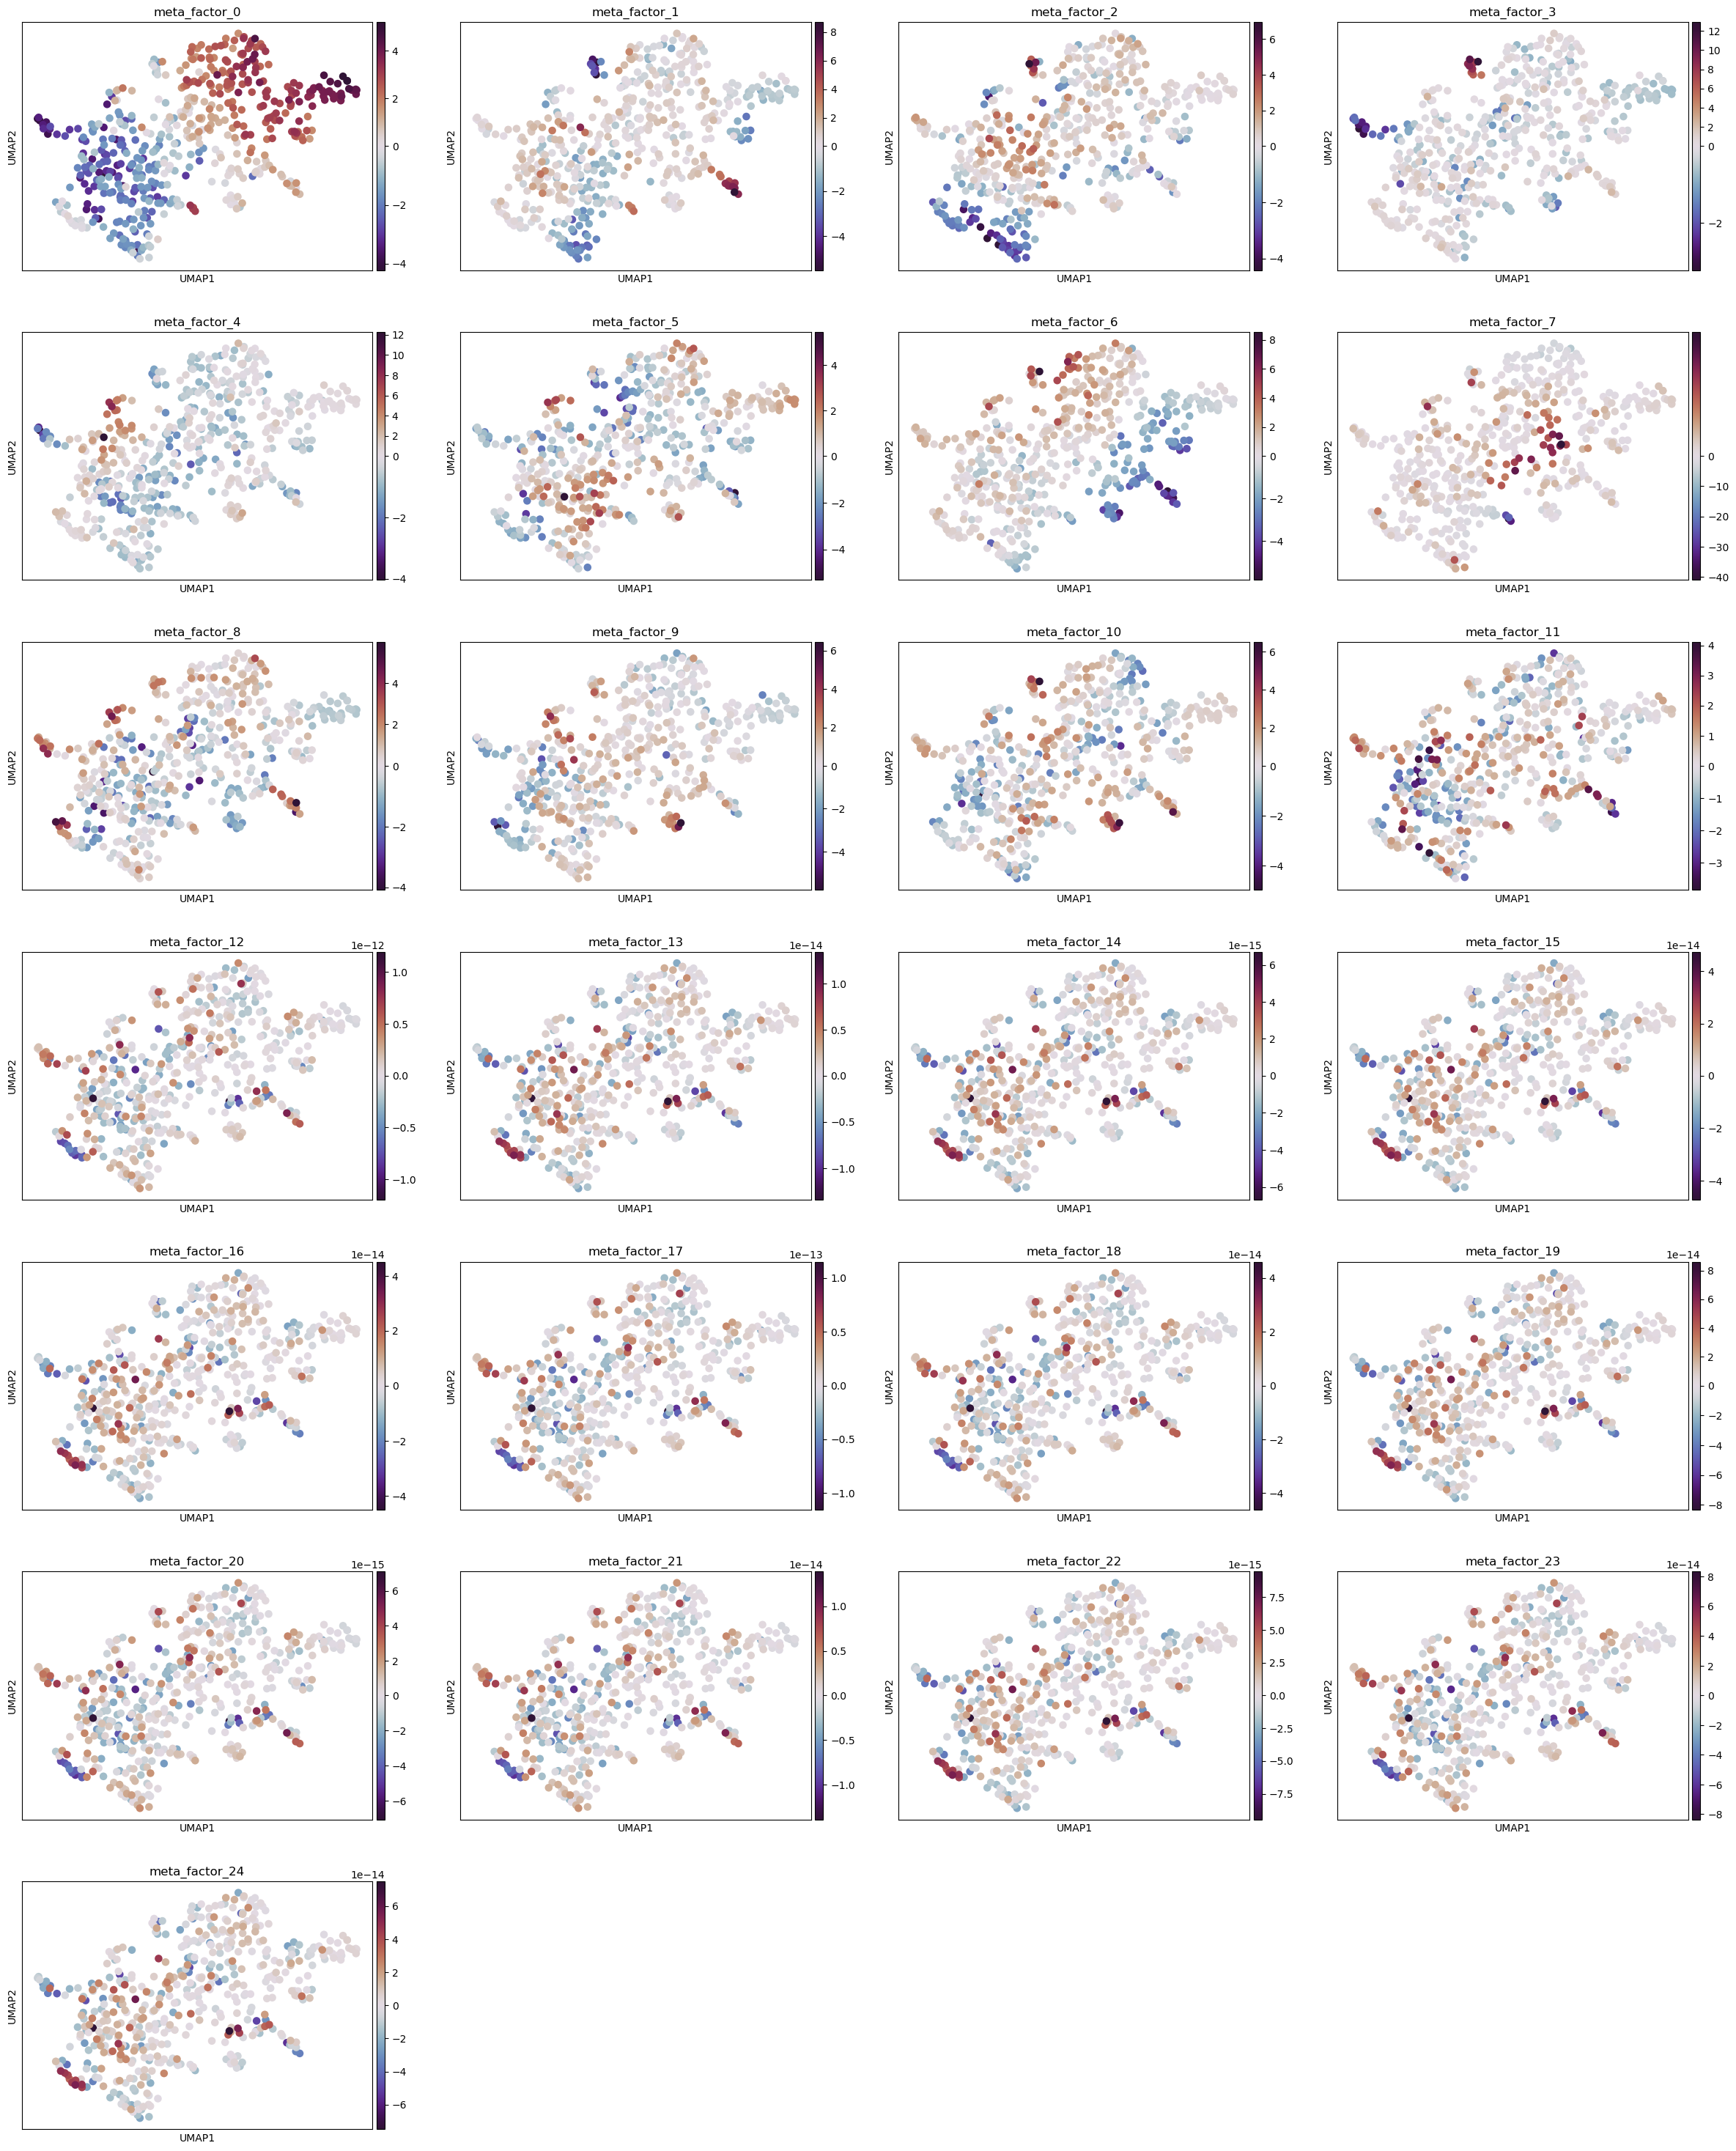

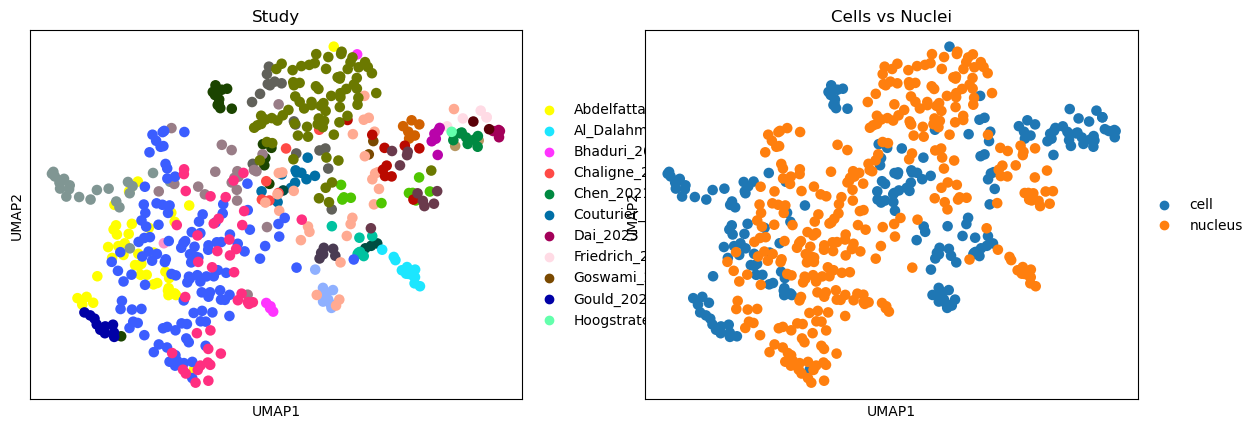

In [12]:
mean_scores_mdata = mu.MuData(adata_dict)
mean_scores_mdata.obs = metadata.loc[mean_scores_mdata.obs.index].astype(str).copy()
m = mean_scores_mdata.copy()
m.obs = pd.DataFrame(index=m.obs_names)
m.obs.index = m.obs.index.astype(str)
m.obs["Cells vs Nuclei"] = mean_scores_mdata.obs["Cells vs Nuclei"].astype(str).values
m.obs["Study"] = mean_scores_mdata.obs["Study"].astype(str).values
for col in ["index", "level_0"]:
    if col in m.obs.columns:
        m.obs = m.obs.drop(columns=col)

mu.tl.mofa(m, groups_label='Cells vs Nuclei', outfile = 'Data/Tissue_States_Meta_MOFA_Models/scfo_exp_meta_mofa_'+disease+'.hdf5', save_metadata=False, n_factors = 25, n_iterations = 3000)
meta_mofa_scores = pd.DataFrame(m.obsm['X_mofa'], index=m.obs.index,)
meta_mofa_weights = pd.DataFrame(m.varm['LFs'],index=m.var_names,)
meta_mofa_scores.columns = [f'meta_factor_{i}' for i in range(meta_mofa_scores.shape[1])]
meta_mofa_weights.columns = [f'meta_factor_{i}' for i in range(meta_mofa_weights.shape[1])]

sc.pp.neighbors(m, use_rep = 'X_mofa')
sc.tl.umap(m)

m.obs[meta_mofa_scores.columns] = meta_mofa_scores.copy()
sc.pl.umap(m, color = meta_mofa_scores.columns, vcenter = 0, cmap = 'twilight_shifted')
sc.pl.umap(m, color = ['Study', 'Cells vs Nuclei'])

meta_mofa_scores.to_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_meta_mofa_'+disease+'_scores.csv')
meta_mofa_weights.to_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_meta_mofa_'+disease+'_weights.csv')

# Composition and expression integration

In [13]:
meta_mofa_scores = pd.read_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_meta_mofa_'+disease+'_scores.csv', index_col = 0)
meta_mofa_weights = pd.read_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_meta_mofa_'+disease+'_weights.csv', index_col = 0)

meta_mofa_weights_sub = meta_mofa_weights[meta_mofa_weights.abs().sum()[meta_mofa_weights.abs().sum() > 1e-8].index]
meta_mofa_scores_sub = meta_mofa_scores[meta_mofa_scores.abs().sum()[meta_mofa_scores.abs().sum() > 1e-8].index]

In [14]:
adata_dict = {
    'exp': ad.AnnData(meta_mofa_scores_sub.copy()),
    'comp': ad.AnnData(fractions_main.copy()),
}
mdata = mu.MuData(adata_dict)
mdata.obs['Cells vs Nuclei'] = metadata.loc[mdata.obs.index, 'Cells vs Nuclei'].copy()

In [15]:
mdata

MuData object with n_obs × n_vars = 519 × 21
  obs:	'Cells vs Nuclei'
  2 modalities
    exp:	519 x 12
    comp:	519 x 9


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='exp' group='cell' with N=198 samples and D=12 features...
Loaded view='exp' group='nucleus' with N=321 samples and D=12 features...
Loaded view='comp' group='cell' with N=198 samples and D=9 features...
Loaded view='comp' group='nucleus' with N=321 samples and D=9 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic

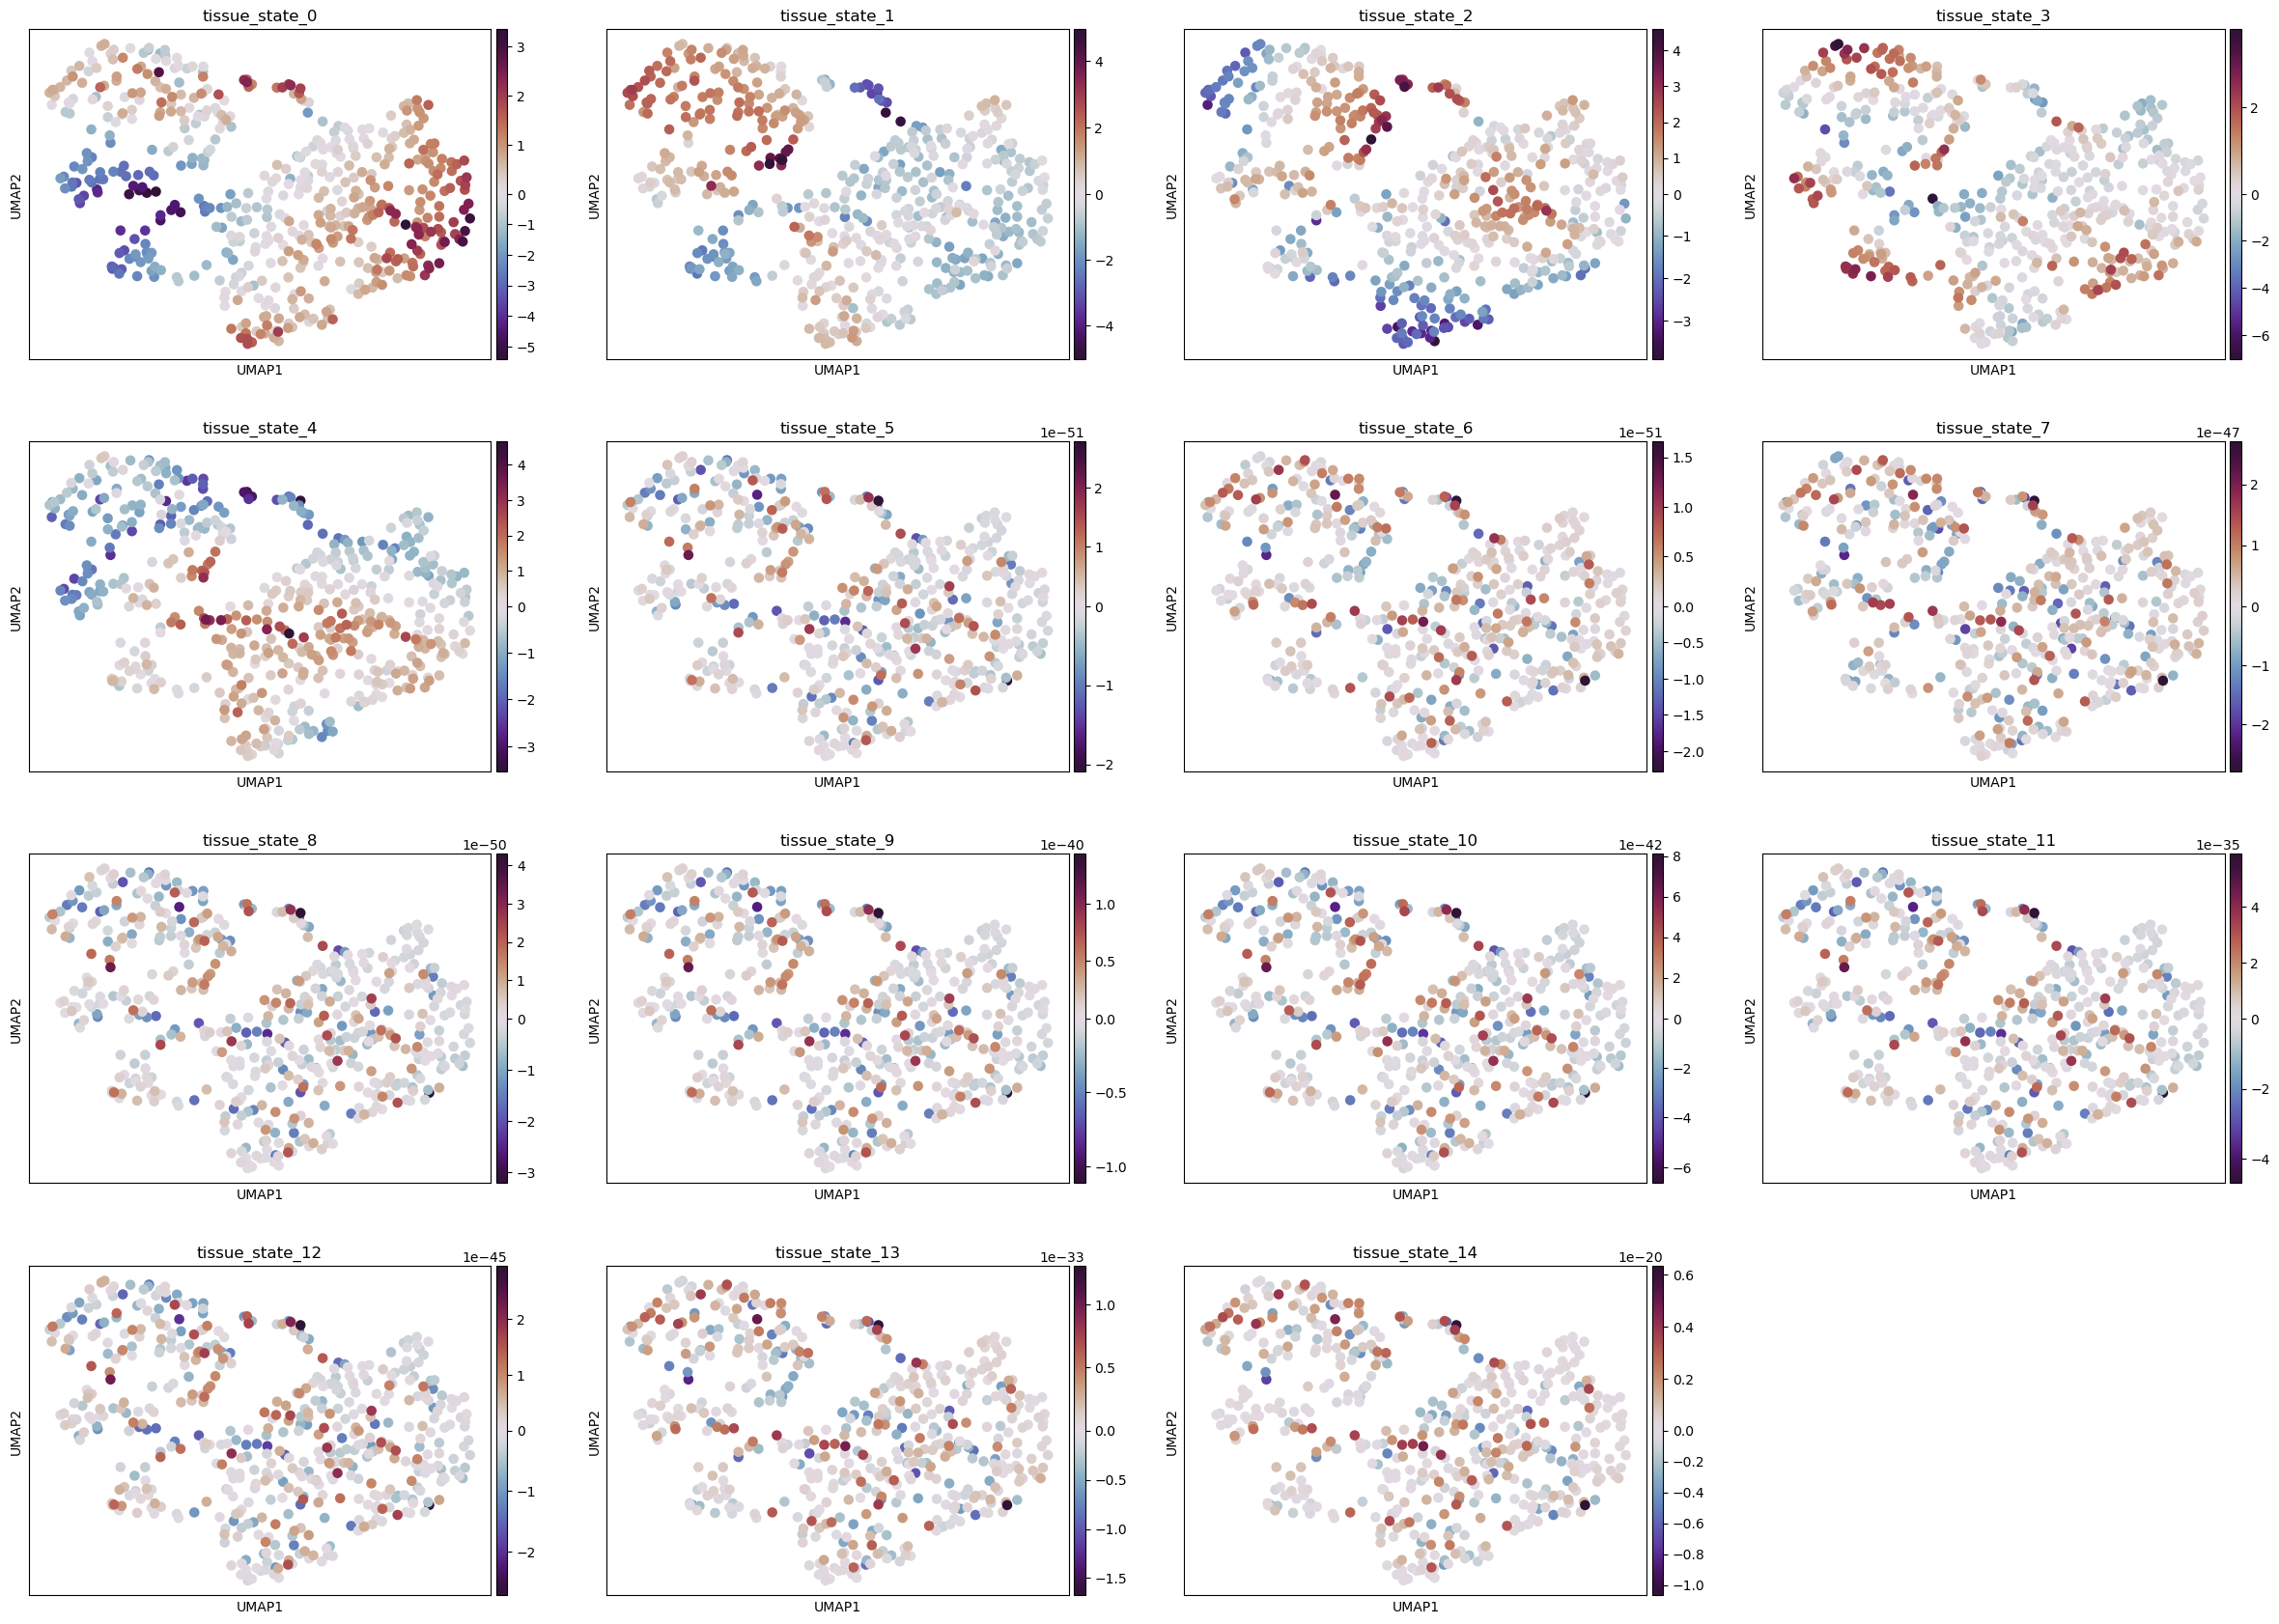

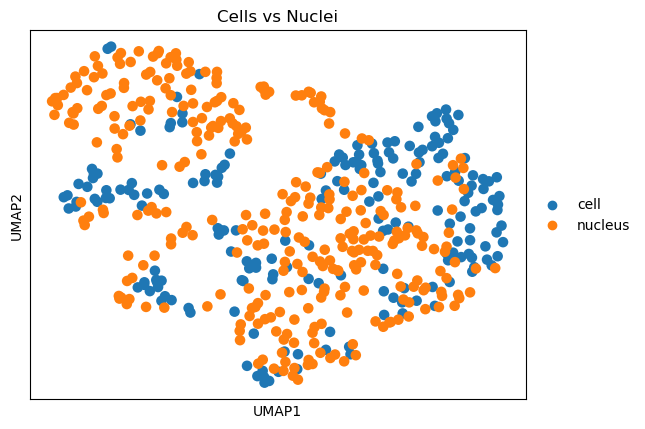

In [16]:
mu.tl.mofa(mdata, groups_label = 'Cells vs Nuclei', outfile = 'Data/Tissue_States_Meta_MOFA_Models/scfo_exp_comp_integration_'+disease+'.hdf5', save_metadata=False, n_factors = 15, n_iterations = 3000)
comp_exp_mofa_scores = pd.DataFrame(mdata.obsm['X_mofa'], index=mdata.obs.index,)
comp_exp_mofa_weights = pd.DataFrame(mdata.varm['LFs'],index=mdata.var_names,)
comp_exp_mofa_scores.columns = [f'tissue_state_{i}' for i in range(comp_exp_mofa_scores.shape[1])]
comp_exp_mofa_weights.columns = [f'tissue_state_{i}' for i in range(comp_exp_mofa_weights.shape[1])]

sc.pp.neighbors(mdata, use_rep = 'X_mofa')
sc.tl.umap(mdata)

mdata.obs[comp_exp_mofa_scores.columns] = comp_exp_mofa_scores.copy()
sc.pl.umap(mdata, color = comp_exp_mofa_scores.columns, vcenter = 0, cmap = 'twilight_shifted')
sc.pl.umap(mdata, color = ['Cells vs Nuclei'])

comp_exp_mofa_scores.to_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_comp_integration_'+disease+'_scores.csv')
comp_exp_mofa_weights.to_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_comp_integration_'+disease+'_weights.csv')

# --------------- Projection and characterization ---------------

# Tissue state projection - single cell

In [17]:
comp_exp_mofa_weights = pd.read_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_comp_integration_'+disease+'_weights.csv', index_col = 0)
comp_exp_mofa_weights_sub = comp_exp_mofa_weights[comp_exp_mofa_weights.abs().sum()[comp_exp_mofa_weights.abs().sum() > 1e-8].index]

meta_mofa_weights = pd.read_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_meta_mofa_'+disease+'_weights.csv', index_col = 0)
meta_mofa_weights_sub = meta_mofa_weights[meta_mofa_weights.abs().sum()[meta_mofa_weights.abs().sum() > 1e-8].index]

In [18]:
ontology_meta = scfo.make_ontology(comp_exp_mofa_weights_sub)

In [19]:
metadata_use = metadata_all[(metadata_all['Lineage enrichment'] == 'no')].copy()
scores_all = pd.concat([mean_scores_all.loc[metadata_use.index], std_scores_all.loc[metadata_use.index]], axis = 1)
scores_all.drop(columns = scores_all.columns[scores_all.columns.astype(str).str.contains('Astrocyte::')], inplace = True)
meta_scores_proj = scores_all.fillna(0) @ meta_mofa_weights_sub.loc[scores_all.columns]
meta_scores_proj_z = (meta_scores_proj - meta_scores_proj.mean()) / meta_scores_proj.std()

In [20]:
sc_all = pd.concat([fractions_main, meta_scores_proj_z], axis = 1).fillna(0)
sc_all_adata = ad.AnnData(sc_all.copy())

scfo.project_ontology(
    adata = sc_all_adata,
    ontology = ontology_meta,
    method = 'permutation',
    n_iter = 100000
)

tissue_states_sc = pd.DataFrame(sc_all_adata.obsm['scfo_scores'].todense(), index = sc_all_adata.obs.index, columns = ontology_meta.obs.index)
tissue_states_sc.to_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_SC_'+disease+'.csv')

Permuting globally...:   0%|          | 0/100000 [00:00<?, ?it/s]

# Association with metadata

In [21]:
tissue_states_sc_z = pd.read_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_SC_'+disease+'.csv', index_col = 0)

In [22]:
cols = ['TERT', 
        'EGFR_mut', 'ATRX_mut', 
        #'EGFR', 'ATRX',
        'MGMT', 'RT', 'Steroids', 'Chemo', 'Status', 'Age', 'Sex', 'Lobe', 'Laterality', 
        'edge_v_core'
       ]
meta_sub = metadata[cols].replace('Unk', np.nan)
metadata_all_dummies = pd.get_dummies(meta_sub, drop_first = False)
for col in cols:
    dummy_cols = [c for c in metadata_all_dummies.columns if c.startswith(f"{col}_")]
    if dummy_cols:
        metadata_all_dummies.loc[meta_sub[col].isna(), dummy_cols] = np.nan
#metadata_all_dummies.drop(columns = ['edge_v_core_NICHE_SVZ', 'edge_v_core_NORMAL', 'Lobe_Other', 'Laterality_Bil'], inplace = True)
common_indices = list(set(metadata_all_dummies.index) & set(tissue_states_sc_z.index))
metadata_all_dummies_sub = metadata_all_dummies.loc[common_indices]
#metadata_all_dummies['MGMT_M'] = np.where(metadata_all_dummies['MGMT_P'] == 1, np.nan, metadata_all_dummies['MGMT_M'])
#metadata_all_dummies['MGMT_U'] = np.where(metadata_all_dummies['MGMT_P'] == 1, np.nan, metadata_all_dummies['MGMT_U'])

all_log_r_ls = []
for variable in ['Sex_F','TERT_mut', 
                 'EGFR_mut_mut', 'ATRX_mut_mut',
                 #'EGFR_mut', 'ATRX_mut',
                 'MGMT_M', 'RT_1', 'Steroids_1', 'Chemo_1', 'Status_Recurrent', 
                 'edge_v_core_EDGE'
                ]:
    try:
        y = metadata_all_dummies_sub[variable].dropna().astype(int)
        X = tissue_states_sc_z.loc[y.index].copy()
    
        model = LogisticRegression(max_iter=100000)
        model.fit(X, y)
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]
        coef_df = pd.DataFrame(model.coef_[0], index = X.columns, columns = [variable])
        all_log_r_ls.append(coef_df)
    except Exception as e:
        print(e)

clinical_df = pd.concat(all_log_r_ls, axis = 1)

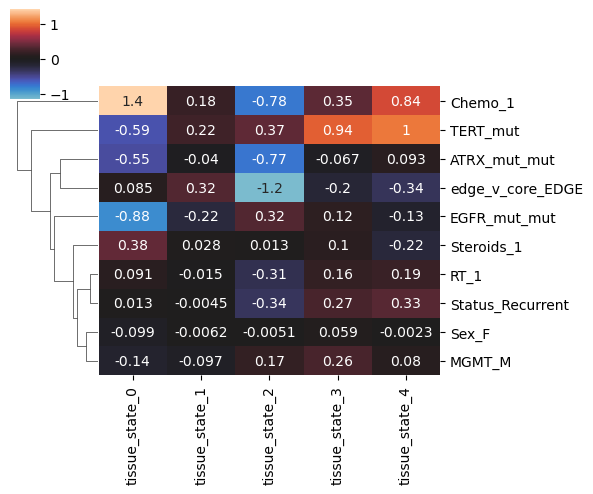

In [23]:
sns.clustermap(clinical_df.T, center = 0, annot = True, figsize = (6,5), col_cluster = False)

In [24]:
clinical_df.to_csv('Data/Tissue_States_Scores_Features/Clinical_spearman_'+disease+'.csv')

# Tumor biology

In [25]:
def calculate_spearman(
    tissue_states_sc_z,
    prof_mean,
    prof_std
):
    prof_tumor_mean = prof_mean[prof_mean.final_annotation_fine == 'Tumor'].drop(columns = 'final_annotation_fine').apply(
        lambda s: s.replace({
            np.inf: s[np.isfinite(s)].max(),
            -np.inf: s[np.isfinite(s)].min()
        })
    )
    prof_tumor_mean.columns = prof_tumor_mean.columns.astype(str) + "::mean"
    
    prof_tumor_std = prof_std[prof_std.final_annotation_fine == 'Tumor'].drop(columns = 'final_annotation_fine').apply(
        lambda s: s.replace({
            np.inf: s[np.isfinite(s)].max(),
            -np.inf: s[np.isfinite(s)].min()
        })
    )
    prof_tumor_std.columns = prof_tumor_std.columns.astype(str) + "::std"
    
    prof_tumor = pd.concat([prof_tumor_mean, prof_tumor_std], axis = 1)

    common_indices = list(set(prof_tumor.index) & set(tissue_states_sc_z.index))
    
    prof_tumor_sub = prof_tumor.loc[common_indices]
    tissue_states_sc_z_sub = tissue_states_sc_z.loc[common_indices]
    
    prof_tumor_sub_z = (prof_tumor_sub - prof_tumor_sub.mean()) / prof_tumor_sub.std()
    
    out = pd.DataFrame(index=prof_tumor_sub_z.columns, columns=tissue_states_sc_z_sub.columns, dtype=float)
    
    for c1 in prof_tumor_sub_z.columns:
        for c2 in tissue_states_sc_z_sub.columns:
            mask = prof_tumor_sub_z[c1].notna() & tissue_states_sc_z_sub[c2].notna()
            if mask.sum() < 2:
                out.loc[c1, c2] = np.nan
            else:
                out.loc[c1, c2] = spearmanr(prof_tumor_sub_z.loc[mask, c1], tissue_states_sc_z_sub.loc[mask, c2]).statistic


    return out

In [26]:
from scipy.stats import spearmanr

In [27]:
tissue_states_sc_z = pd.read_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_SC_'+disease+'.csv', index_col = 0)

In [28]:
### Tumor signatures
prof_mean = pd.read_csv('Data/Tissue_States_Scores_Biopsies/tumor_signature_scores_grouped_mean.csv', index_col = 0).set_index('Sample_Study')
prof_std = pd.read_csv('Data/Tissue_States_Scores_Biopsies/tumor_signature_scores_grouped_std.csv', index_col = 0).set_index('Sample_Study')

calculate_spearman(
    tissue_states_sc_z,
    prof_mean,
    prof_std
).to_csv('Data/Tissue_States_Scores_Features/tumor_signature_scores_spearman_'+disease+'.csv')

In [31]:
if (disease == 'combined'):
    disease_load = 'gbm'
else:
    disease_load = disease

In [32]:
### CNV profile

prof_mean = pd.read_csv('Data/Tissue_States_Scores_Biopsies/all_cnv_profile_grouped_mean_'+disease_load+'.csv', index_col = 0).fillna(0).set_index('Sample_Study')
prof_std = pd.read_csv('Data/Tissue_States_Scores_Biopsies/all_cnv_profile_grouped_std_'+disease_load+'.csv', index_col = 0).fillna(0).set_index('Sample_Study')

calculate_spearman(
    tissue_states_sc_z,
    prof_mean,
    prof_std
).to_csv('Data/Tissue_States_Scores_Features/all_cnv_profile_spearman_'+disease+'.csv')

In [33]:
### CNV summary scores

prof_mean = pd.read_csv('Data/Tissue_States_Scores_Biopsies/all_tumor_cnv_scores_grouped_mean_'+disease_load+'.csv', index_col = 0).fillna(0).set_index('Sample_Study')
prof_std = pd.read_csv('Data/Tissue_States_Scores_Biopsies/all_tumor_cnv_scores_grouped_std_'+disease_load+'.csv', index_col = 0).fillna(0).set_index('Sample_Study')

calculate_spearman(
    tissue_states_sc_z,
    prof_mean,
    prof_std
).to_csv('Data/Tissue_States_Scores_Features/all_tumor_scores_spearman_'+disease+'.csv')

# Survival Scores

In [34]:
surv_weights = pd.read_csv('Data/scFO_Priors/all_pathway_profile.csv', index_col = 0)
surv_weights['metric'] = np.where(surv_weights.index.astype(str).str.contains('mean'), 'mean', 'std')
surv_weights.index = surv_weights.index.astype(str).str.replace('mean', '')
surv_weights.index = surv_weights.index.astype(str).str.replace('std', '')
surv_weights.index = surv_weights.index.astype(str).str.replace('__', '|', regex = False)
surv_weights.index = surv_weights.index.astype(str) + '::' + surv_weights.metric.astype(str)
surv_weights.drop(columns = 'metric', inplace = True)

In [35]:
metadata_use = metadata_all[(metadata_all['Lineage enrichment'] == 'no')].copy()
scores_all = pd.concat([mean_scores_all.loc[metadata_use.index], std_scores_all.loc[metadata_use.index]], axis = 1)

In [36]:
common_indices = list(set(surv_weights.index) & set(scores_all.columns))
surv_scores = scores_all[common_indices].fillna(0) @ surv_weights.loc[common_indices]
surv_scores_z = (surv_scores - surv_scores.mean()) / surv_scores.std()

surv_scores_z.to_csv('Data/Tissue_States_Scores_Biopsies/Survival_scores_'+disease+'.csv')

In [37]:
surv_scores_z = pd.read_csv('Data/Tissue_States_Scores_Biopsies/Survival_scores_'+disease+'.csv', index_col = 0)

In [38]:
tissue_states_sc_z = pd.read_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_SC_'+disease+'.csv', index_col = 0)

In [39]:
common_indices = list(set(surv_scores_z.index) & set(tissue_states_sc_z.index))

In [40]:
surv_scores_z_sub = surv_scores_z.loc[common_indices]
tissue_states_sc_z_sub = tissue_states_sc_z.loc[common_indices]

In [41]:
from scipy.stats import spearmanr
out = pd.DataFrame(index=surv_scores_z_sub.columns, columns=tissue_states_sc_z_sub.columns, dtype=float)

for c1 in surv_scores_z_sub.columns:
    for c2 in tissue_states_sc_z_sub.columns:
        mask = surv_scores_z_sub[c1].notna() & tissue_states_sc_z_sub[c2].notna()
        if mask.sum() < 2:
            out.loc[c1, c2] = np.nan
        else:
            out.loc[c1, c2] = spearmanr(surv_scores_z_sub.loc[mask, c1], tissue_states_sc_z_sub.loc[mask, c2]).statistic

In [42]:
out.to_csv('Data/Tissue_States_Scores_Features/Survival_spearman_'+disease+'.csv')

# Build tissue state feature ontology

In [61]:
comp_exp_mofa_weights = pd.read_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_comp_integration_'+disease+'_weights.csv', index_col = 0)
comp_exp_mofa_weights_sub = comp_exp_mofa_weights[comp_exp_mofa_weights.abs().sum()[comp_exp_mofa_weights.abs().sum() > 1e-8].index]

meta_mofa_weights = pd.read_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_meta_mofa_'+disease+'_weights.csv', index_col = 0)
meta_mofa_weights_sub = meta_mofa_weights[meta_mofa_weights.abs().sum()[meta_mofa_weights.abs().sum() > 1e-8].index]

In [62]:
tissue_states_ontology = scfo.make_ontology(comp_exp_mofa_weights_sub)
tissue_states_ontology.obs['Classification'] = 'Tissue State'

In [63]:
if (disease == 'combined'):
    metadata_all = pd.read_csv('Data/Single_Cell_Biopsies/biopsy_metadata_combined.csv', index_col = 0)
    metadata = metadata_all[(metadata_all['Lineage enrichment'] == 'no')].copy()
    tissue_states_sc_z = pd.read_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_SC_combined.csv', index_col = 0)
    tissue_states_sc_z['disease_group'] = metadata.loc[tissue_states_sc_z.index, 'disease_group']
    disease_means = tissue_states_sc_z.groupby('disease_group').mean()
    disease_means.index = disease_means.index.astype(str) + '::mean'
    disease_stds = tissue_states_sc_z.groupby('disease_group').std()
    disease_stds.index = disease_stds.index.astype(str) + '::std'
    disease_scores = pd.concat([disease_means, disease_stds])
    scfo.add_modality(
        tissue_states_ontology,
        modality_name = 'disease_association',
        score_df = disease_scores.T,
        modality_type = 'precomputed'
    )

In [64]:
loadings = tissue_states_ontology.mod['weights'].to_df()
abundance_loadings = loadings[loadings.columns[loadings.columns.astype(str).str.contains('abundance')]].T
abundance_loadings.index = abundance_loadings.index.astype(str).str.split('~').str[0]
abundance_loadings.index = abundance_loadings.index.astype(str).str.replace('Non_Mac_Myelocyte', 'Non_Mac')

scfo.add_modality(
    tissue_states_ontology,
    modality_name = 'cell type abundance',
    score_df = abundance_loadings.T,
    modality_type = 'precomputed'
)

In [65]:
clinical_df = pd.read_csv('Data/Tissue_States_Scores_Features/Clinical_spearman_'+disease+'.csv', index_col = 0).T
clinical_df.index = clinical_df.index.astype(str).str.replace('MGMT methylated', 'MGMT meth.')
clinical_df.index = clinical_df.index.astype(str).str.replace('EGFR amplification', 'EGFR amp.')

scfo.add_modality(
    tissue_states_ontology,
    modality_name = 'clinical',
    score_df = clinical_df.T,
    modality_type = 'precomputed'
)

In [66]:
survival_scores = pd.read_csv('Data/Tissue_States_Scores_Features/Survival_spearman_'+disease+'.csv', index_col = 0)

scfo.add_modality(
    tissue_states_ontology,
    modality_name = 'survival',
    score_df = survival_scores.T,
    modality_type = 'precomputed'
)

In [67]:
sigs_1 = pd.read_csv('Data/Tissue_States_Scores_Features/all_cnv_profile_spearman_'+disease+'.csv', index_col = 0)
sigs_2 = pd.read_csv('Data/Tissue_States_Scores_Features/all_tumor_scores_spearman_'+disease+'.csv', index_col = 0).loc[[
    'cnv_corr::mean', 'cnv_signal::mean', 'cnv_7_10::mean',
    'cnv_corr::std', 'cnv_signal::std', 'cnv_7_10::std',
]]
sigs = pd.concat([sigs_1, sigs_2])

scfo.add_modality(
    tissue_states_ontology,
    modality_name = 'cnv_scores',
    score_df = sigs.T,
    modality_type = 'precomputed'
)

In [68]:
if not (disease == 'lgg'):
    sigs = pd.read_csv('Data/Tissue_States_Scores_Features/tumor_signature_scores_spearman_'+disease+'.csv', index_col = 0)
    
    scfo.add_modality(
        tissue_states_ontology,
        modality_name = 'tumor_signatures',
        score_df = sigs.T,
        modality_type = 'precomputed'
    )

In [69]:
meta_mofa_weights_sub_mean = meta_mofa_weights_sub[meta_mofa_weights_sub.index.astype(str).str.endswith('::mean')].copy()
meta_mofa_weights_sub_mean.index = meta_mofa_weights_sub_mean.index.astype(str).str.split('::').str[0]
meta_mofa_weights_sub_std = meta_mofa_weights_sub[meta_mofa_weights_sub.index.astype(str).str.endswith('::std')].copy()
meta_mofa_weights_sub_std.index = meta_mofa_weights_sub_std.index.astype(str).str.split('::').str[0]

comp_exp_mofa_weights_sub_meta = comp_exp_mofa_weights_sub.loc[comp_exp_mofa_weights_sub.index.astype(str).str.contains('meta')]

scfo.add_modality(
    tissue_states_ontology,
    modality_name = 'scfo_factors_mean',
    score_df = comp_exp_mofa_weights_sub_meta.T @ meta_mofa_weights_sub_mean.T,
    feature_loadings = meta_mofa_weights_sub_mean.T,
    modality_type = 'precomputed'
)

scfo.add_modality(
    tissue_states_ontology,
    modality_name = 'scfo_factors_std',
    score_df = comp_exp_mofa_weights_sub_meta.T @ meta_mofa_weights_sub_std.T,
    feature_loadings = meta_mofa_weights_sub_std.T,
    modality_type = 'precomputed'
)

In [70]:
all_genes_ls = []
for cell_type in ontology.obs.Classification.unique():
    if (cell_type == 'Astrocyte'):
        print('skip')
    else:
        ts_scfo_mean = scfo.modality_scores_to_df(
            tissue_states_ontology,
            modality = 'scfo_factors_mean',
        )
        
        scfo_genes = scfo.factor_weights_to_df(
            ontology, 
            transpose = False, 
            cell_types = cell_type
        )
        
        ts_genes_mean = (ts_scfo_mean[scfo_genes.index] @ scfo_genes).T
        ts_genes_mean = ts_genes_mean.loc[ts_genes_mean.abs().sum(axis = 1)[ts_genes_mean.abs().sum(axis = 1) > 0].index].T
    
        scfo.add_modality(
            tissue_states_ontology,
            modality_name = 'genes_'+cell_type,
            score_df = ts_genes_mean,
            modality_type = 'precomputed'
        )
        
        ts_genes_mean.columns = ts_genes_mean.columns + '_' + cell_type
        all_genes_ls.append(ts_genes_mean)

all_genes = pd.concat(all_genes_ls, axis = 1)

scfo.add_modality(
    tissue_states_ontology,
    modality_name = 'weights',
    score_df = all_genes,
    modality_type = 'precomputed'
)

skip


In [71]:
all_tfs_ls = []
for cell_type in ontology.obs.Classification.unique():
    if (cell_type == 'Astrocyte'):
        print('skip')
    else:
        ts_scfo_mean = scfo.modality_scores_to_df(
            tissue_states_ontology,
            modality = 'scfo_factors_mean',
        )
        
        scfo_tfs = scfo.modality_scores_to_df(
            ontology, 
            modality = 'regulons',
            cell_types = cell_type
        ).dropna(how = 'all', axis = 1)
        
        ts_genes_mean = (ts_scfo_mean[scfo_tfs.index] @ scfo_tfs).T
        ts_genes_mean = ts_genes_mean.loc[ts_genes_mean.abs().sum(axis = 1)[ts_genes_mean.abs().sum(axis = 1) > 0].index].T
        ts_genes_mean.columns = ts_genes_mean.columns + '_' + cell_type
        all_tfs_ls.append(ts_genes_mean)

all_tfs_GBM = pd.concat(all_tfs_ls, axis = 1)

if (disease == 'combined'):
    all_tfs_ls = []
    for cell_type in ontology.obs.Classification.unique():
        ts_scfo_mean = scfo.modality_scores_to_df(
            tissue_states_ontology,
            modality = 'scfo_factors_mean',
        )
        
        scfo_tfs = scfo.modality_scores_to_df(
            ontology, 
            modality = 'regulons_LGG',
            cell_types = cell_type
        ).dropna(how = 'all', axis = 1)
        
        ts_genes_mean = (ts_scfo_mean[scfo_tfs.index] @ scfo_tfs).T
        ts_genes_mean = ts_genes_mean.loc[ts_genes_mean.abs().sum(axis = 1)[ts_genes_mean.abs().sum(axis = 1) > 0].index].T
        ts_genes_mean.columns = ts_genes_mean.columns + '_' + cell_type
        all_tfs_ls.append(ts_genes_mean)

    all_tfs_LGG = pd.concat(all_tfs_ls, axis = 1)

scfo.add_modality(
    tissue_states_ontology,
    modality_name = 'regulons',
    score_df = all_tfs_GBM,
    modality_type = 'precomputed'
)
if (disease == 'combined'):
    scfo.add_modality(
        tissue_states_ontology,
        modality_name = 'regulons_LGG',
        score_df = all_tfs_LGG,
        modality_type = 'precomputed'
    )

skip


In [72]:
tissue_states_ontology.write_h5mu('scFO_Models/scfo_tissue_states_'+disease+'.h5mu')

In [73]:
tissue_states_ontology

MuData object with n_obs × n_vars = 5 × 42822
  obs:	'FactorName', 'Classification', 'Number', 'FactorType'
  uns:	'gene_names', 'factor_type', 'modality_names'
  19 modalities
    weights:	5 x 20402
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    cell type abundance:	5 x 9
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    clinical:	5 x 10
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    survival:	5 x 5
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    cnv_scores:	5 x 52
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    tumor_signatures:	5 x 50
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    scfo_factors_mean:	5 x 250
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
    scfo_factors_std:	5 x 250
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
    genes_Tumor:	5 x 2016
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    genes_Mo_TAM:	5 x 2042
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    genes_Mg_TAM:	5 x 2045
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    genes_T cell:	5 x 2038
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    genes_Neuron:	5 x 2049
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    genes_Oligo:	5 x 2027
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    genes_Pericyte:	5 x 2045
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    genes_Endothelial:	5 x 2045
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'sc